# 🛒 Retail Intelligence Platform — 01: Exploratory Data Analysis & Data Quality Profiling

**Objetivo:** Realizar una auditoría profunda de calidad de datos, patrones de estacionalidad, dinámicas de negocio retail en Ecuador y anomalías exógenas (petróleo, terremoto 2016, feriados y promociones) para fundamentar las decisiones de ingeniería de características y modelado.

---

### 📋 Estructura del Análisis:
1. **Configuración del Entorno & Carga de Datos**
2. **Dimensiones, Esquemas e Integridad Temporal**
3. **Análisis de la Variable Objetivo (`sales`)**
   - Evolución temporal agregada y anomalías históricas (Terremoto 2016).
   - Fenómeno de ventas en cero (*Zero-Inflation / Intermittent Demand*).
4. **Patrones de Estacionalidad de Retail**
   - Estacionalidad Semanal (efecto fin de semana).
   - Efecto Quincenal de Nómina en Ecuador (días 15 y fin de mes).
   - Estacionalidad Anual y cierre de tiendas el 25 de diciembre.
5. **Estructura Jerárquica: Tiendas y Familias de Productos**
   - Análisis de Pareto por Familias (80/20 de ingresos).
   - Dispersión geográfica y tipología de tiendas.
6. **Variables Exógenas y Factores Externos**
   - Precio del Petróleo WTI (`oil.csv`): nulos, fines de semana y correlación macro.
   - Feriados Nacionales, Regionales, Locales y Transferidos (`holidays_events.csv`).
   - Dinámica de Promociones (`onpromotion`): quiebre histórico de 2013-2014.
7. **Conclusiones Ejecutivas & Implicaciones de Arquitectura**

In [3]:
# Imports estándar de análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Configuración de estilos visuales profesionales
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Rutas de datos
RAW_DATA_PATH = Path('../data/raw')
print("Entorno configurado correctamente.")

Entorno configurado correctamente.


## 1. Carga de Datos y Verificación de Integridad

Cargamos los datasets principales para analizar sus dimensiones y tipos de datos iniciales.

In [4]:
# Carga de datasets con parseo de fechas
train_df = pd.read_csv(RAW_DATA_PATH / 'train.csv', parse_dates=['date'])
test_df = pd.read_csv(RAW_DATA_PATH / 'test.csv', parse_dates=['date'])
stores_df = pd.read_csv(RAW_DATA_PATH / 'stores.csv')
oil_df = pd.read_csv(RAW_DATA_PATH / 'oil.csv', parse_dates=['date'])
holidays_df = pd.read_csv(RAW_DATA_PATH / 'holidays_events.csv', parse_dates=['date'])
transactions_df = pd.read_csv(RAW_DATA_PATH / 'transactions.csv', parse_dates=['date'])

# Resumen de dimensiones
summary_table = pd.DataFrame({
    'Dataset': ['train', 'test', 'stores', 'oil', 'holidays_events', 'transactions'],
    'Filas': [len(train_df), len(test_df), len(stores_df), len(oil_df), len(holidays_df), len(transactions_df)],
    'Columnas': [train_df.shape[1], test_df.shape[1], stores_df.shape[1], oil_df.shape[1], holidays_df.shape[1], transactions_df.shape[1]],
    'Fecha Inicio': [train_df['date'].min().strftime('%Y-%m-%d'), test_df['date'].min().strftime('%Y-%m-%d'), '-', oil_df['date'].min().strftime('%Y-%m-%d'), holidays_df['date'].min().strftime('%Y-%m-%d'), transactions_df['date'].min().strftime('%Y-%m-%d')],
    'Fecha Fin': [train_df['date'].max().strftime('%Y-%m-%d'), test_df['date'].max().strftime('%Y-%m-%d'), '-', oil_df['date'].max().strftime('%Y-%m-%d'), holidays_df['date'].max().strftime('%Y-%m-%d'), transactions_df['date'].max().strftime('%Y-%m-%d')]
})
summary_table

,Dataset,Filas,Columnas,Fecha Inicio,Fecha Fin
0,train,3000888,6,2013-01-01,2017-08-15
1,test,28512,5,2017-08-16,2017-08-31
2,stores,54,5,-,-
3,oil,1218,2,2013-01-01,2017-08-31
4,holidays_events,350,6,2012-03-02,2017-12-26
5,transactions,83488,3,2013-01-01,2017-08-15


## 2. Análisis de la Variable Objetivo (`sales`)

Analizamos el comportamiento de la demanda global, estacionalidades de largo plazo y eventos atípicos en la historia ecuatoriana.

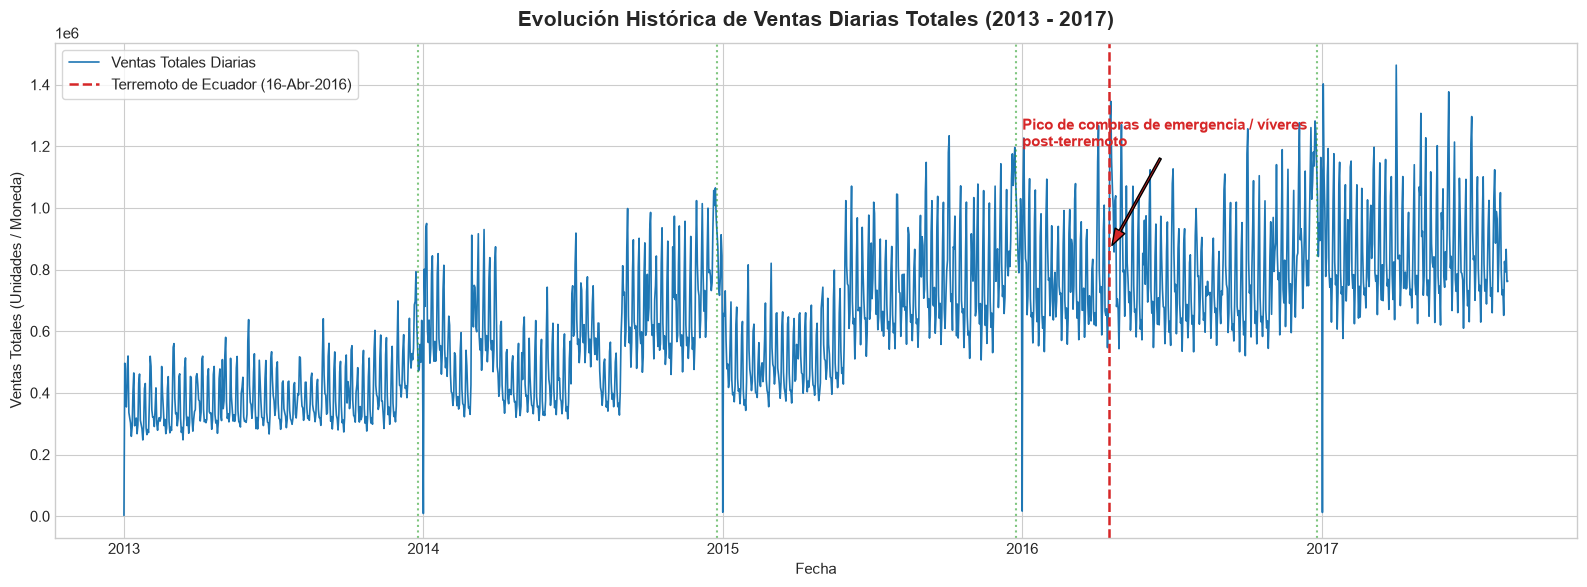

In [5]:
# Ventas globales diarias agregadas
daily_sales = train_df.groupby('date')['sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily_sales['date'], daily_sales['sales'], color='#1f77b4', linewidth=1.2, label='Ventas Totales Diarias')

# Resaltar evento histórico: Terremoto de Manabí (16 de Abril de 2016)
earthquake_date = pd.to_datetime('2016-04-16')
ax.axvline(earthquake_date, color='#d62728', linestyle='--', linewidth=1.8, label='Terremoto de Ecuador (16-Abr-2016)')
ax.annotate('Pico de compras de emergencia / víveres\npost-terremoto', 
            xy=(earthquake_date, daily_sales.loc[daily_sales['date'] == earthquake_date, 'sales'].values[0]),
            xytext=(pd.to_datetime('2016-01-01'), 1.2e6),
            arrowprops=dict(facecolor='#d62728', shrink=0.05, width=1.5, headwidth=8),
            fontsize=11, fontweight='bold', color='#d62728')

# Cierres de Navidad
for year in [2013, 2014, 2015, 2016]:
    ax.axvline(pd.to_datetime(f'{year}-12-25'), color='#2ca02c', linestyle=':', alpha=0.6)

ax.set_title('Evolución Histórica de Ventas Diarias Totales (2013 - 2017)', fontsize=15, pad=12)
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas Totales (Unidades / Moneda)')
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

### 2.1 Diagnóstico de Ventas en Cero (Zero-Inflation)

En retail, los valores de venta $0$ son comunes pero deben entenderse: ¿es falta de inventario, tiendas aún no inauguradas o familias de productos no distribuidas en ciertas tiendas?

Porcentaje total de registros con ventas en cero: 31.30%


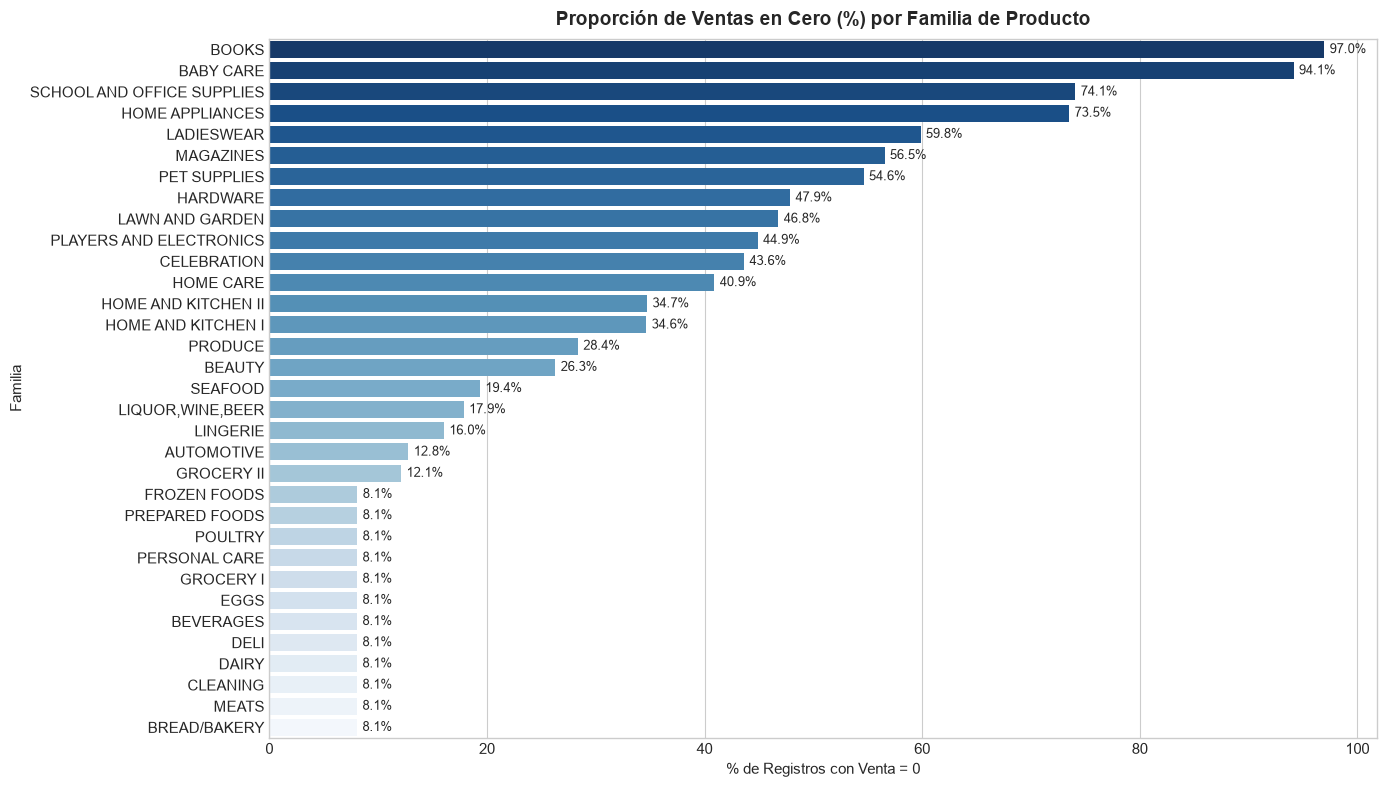

In [6]:
zero_sales_pct = (train_df['sales'] == 0).mean() * 100
print(f"Porcentaje total de registros con ventas en cero: {zero_sales_pct:.2f}%")

# Ceros por familia de producto
zeros_by_family = train_df.groupby('family')['sales'].apply(lambda s: (s == 0).mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(x=zeros_by_family.values, y=zeros_by_family.index, palette='Blues_r', ax=ax)
ax.set_title('Proporción de Ventas en Cero (%) por Familia de Producto', fontsize=14, pad=10)
ax.set_xlabel('% de Registros con Venta = 0')
ax.set_ylabel('Familia')
for i, v in enumerate(zeros_by_family.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Patrones de Estacionalidad de Retail

Analizaremos la estacionalidad en tres escalas de tiempo:
1. **Día de la semana** (patrón intra-semanal).
2. **Día del mes y quincenas** (Efecto del rol de pagos quincenal en Ecuador: días 15 y fin de mes).
3. **Mes del año** (campañas navideñas, día de la madre, etc.).

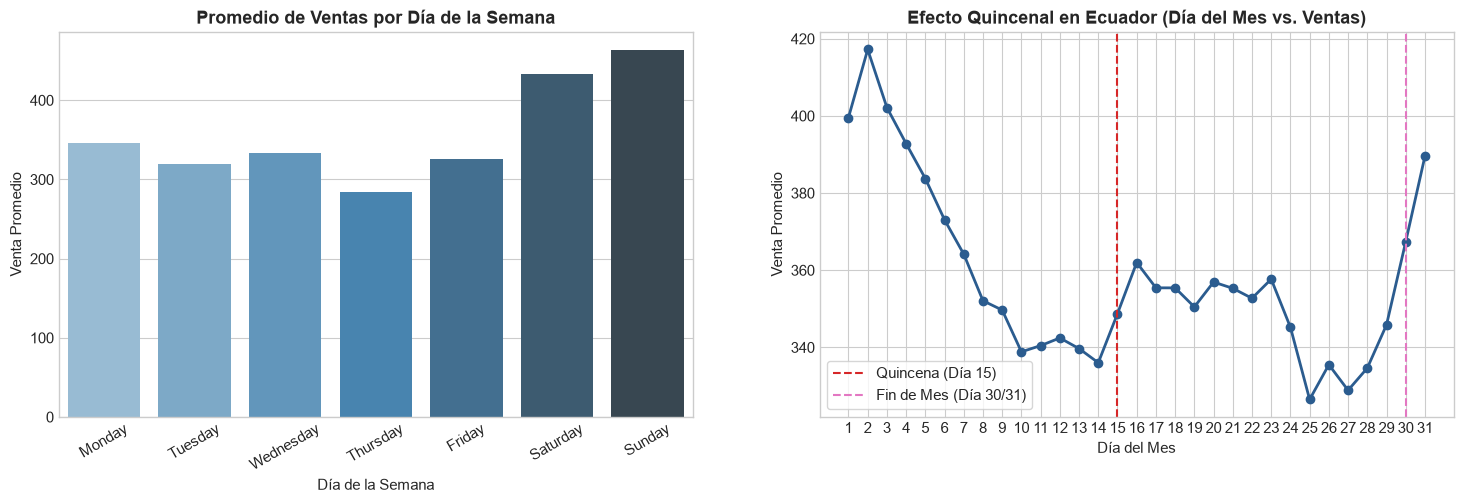

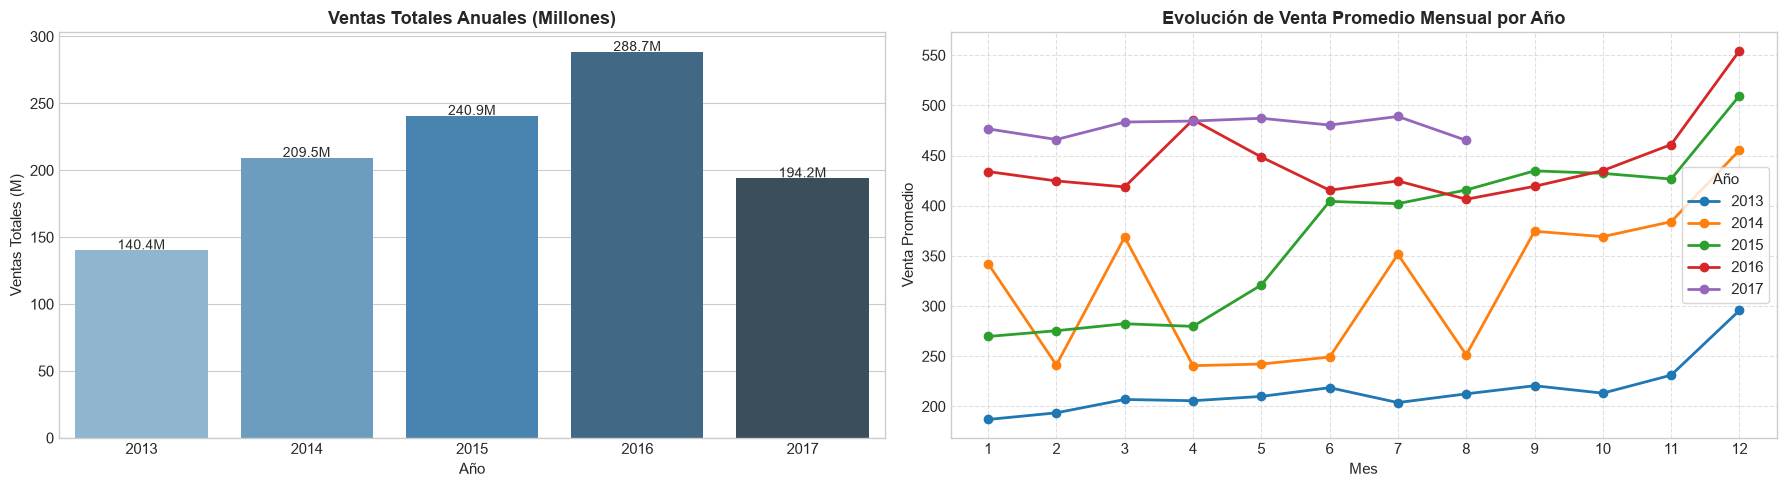

In [8]:
# Enriquecimiento temporal rápido para análisis
train_df['day_of_week'] = train_df['date'].dt.day_name()
train_df['day_of_month'] = train_df['date'].dt.day
train_df['month'] = train_df['date'].dt.month
train_df['year'] = train_df['date'].dt.year

# 1. Estacionalidad por Día de la Semana
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = train_df.groupby('day_of_week')['sales'].mean().reindex(day_order)

# 2. Estacionalidad por Día del Mes (Efecto Quincena)
dom_sales = train_df.groupby('day_of_month')['sales'].mean()

# Gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# Plot Día de la semana
sns.barplot(x=dow_sales.index, y=dow_sales.values, ax=ax1, palette='Blues_d')
ax1.set_title('Promedio de Ventas por Día de la Semana', fontsize=13)
ax1.set_xlabel('Día de la Semana')
ax1.set_ylabel('Venta Promedio')
ax1.tick_params(axis='x', rotation=30)

# Plot Día del mes
ax2.plot(dom_sales.index, dom_sales.values, marker='o', color='#2b5c8f', linewidth=2)
ax2.axvline(15, color='#d62728', linestyle='--', label='Quincena (Día 15)')
ax2.axvline(30, color='#e377c2', linestyle='--', label='Fin de Mes (Día 30/31)')
ax2.set_title('Efecto Quincenal en Ecuador (Día del Mes vs. Ventas)', fontsize=13)
ax2.set_xlabel('Día del Mes')
ax2.set_ylabel('Venta Promedio')
ax2.set_xticks(range(1, 32))
ax2.legend(frameon=True)

# 3. Tendencia Anual y Estacionalidad Mensual
year_sales = train_df.groupby('year')['sales'].sum() / 1e6  # En millones de unidades
monthly_trend = train_df.groupby(['year', 'month'])['sales'].mean().unstack(level=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# Plot 1: Ventas Totales por Año
sns.barplot(x=year_sales.index, y=year_sales.values, ax=ax1, palette='Blues_d')
ax1.set_title('Ventas Totales Anuales (Millones)', fontsize=13)
ax1.set_xlabel('Año')
ax1.set_ylabel('Ventas Totales (M)')
for i, v in enumerate(year_sales.values):
    ax1.text(i, v + 0.5, f'{v:.1f}M', ha='center', fontsize=10)

# Plot 2: Comportamiento Mensual Comparado por Año
monthly_trend.plot(ax=ax2, marker='o', linewidth=2)
ax2.set_title('Evolución de Venta Promedio Mensual por Año', fontsize=13)
ax2.set_xlabel('Mes')
ax2.set_ylabel('Venta Promedio')
ax2.set_xticks(range(1, 13))
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(title='Año', frameon=True)


plt.tight_layout()
plt.show()

## 4. Estructura Jerárquica: Tiendas y Familias de Productos

Analizamos la concentración de ingresos (Curva de Pareto) y la relación entre tipo de tienda y volumen transaccional.

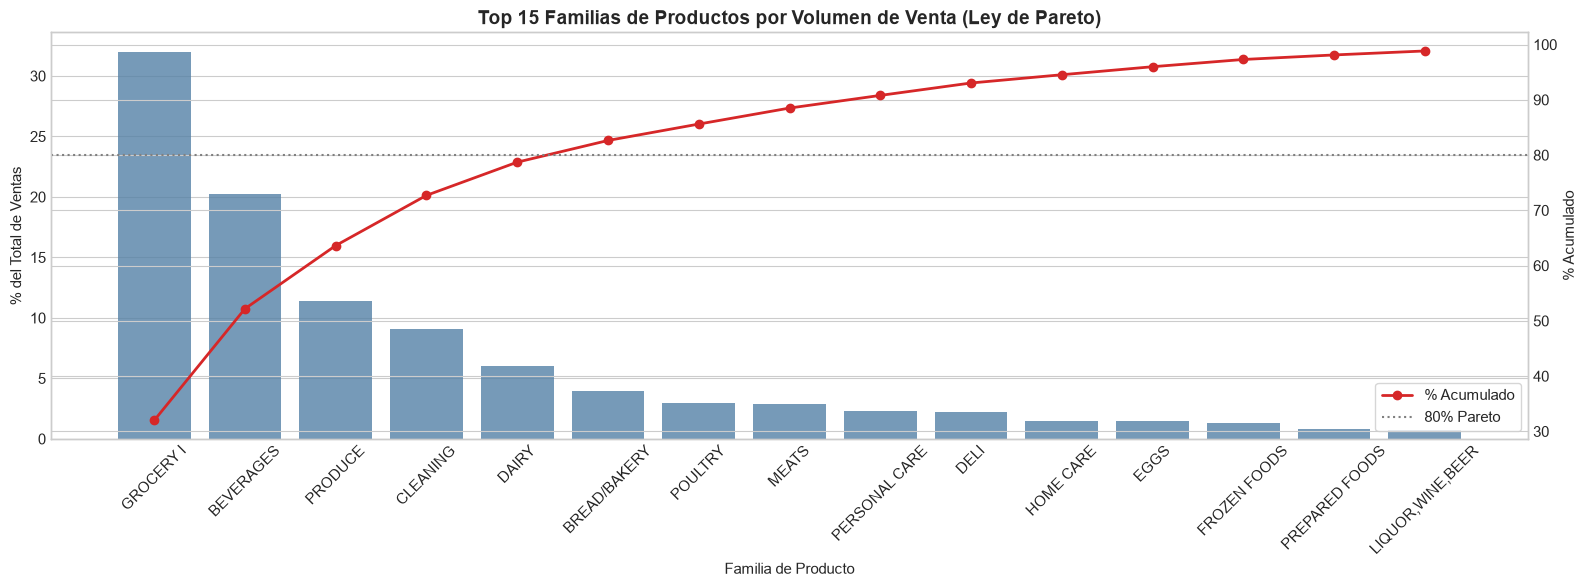

In [9]:
# 1. Pareto de Familias de Productos
family_sales = train_df.groupby('family')['sales'].sum().sort_values(ascending=False)
family_sales_pct = (family_sales / family_sales.sum()) * 100
family_sales_cum = family_sales_pct.cumsum()

fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

sns.barplot(x=family_sales.index[:15], y=family_sales_pct.values[:15], ax=ax1, color='#4682b4', alpha=0.8)
ax2.plot(range(15), family_sales_cum.values[:15], color='#d62728', marker='o', linewidth=2, label='% Acumulado')
ax2.axhline(80, color='gray', linestyle=':', label='80% Pareto')

ax1.set_title('Top 15 Familias de Productos por Volumen de Venta (Ley de Pareto)', fontsize=14)
ax1.set_xlabel('Familia de Producto')
ax1.set_ylabel('% del Total de Ventas')
ax2.set_ylabel('% Acumulado')
ax1.tick_params(axis='x', rotation=45)
ax2.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

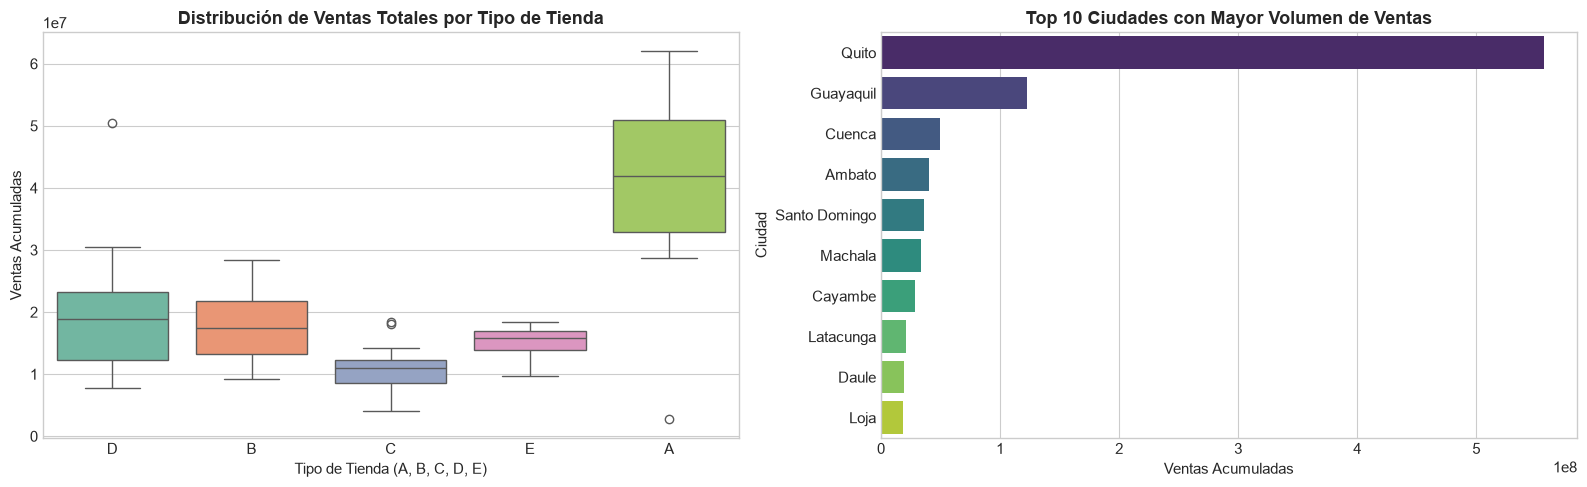

In [10]:
# 2. Análisis por Tipo de Tienda y Ciudad
train_store_merged = train_df.groupby('store_nbr')['sales'].sum().reset_index().merge(stores_df, on='store_nbr')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=train_store_merged, x='type', y='sales', ax=ax1, palette='Set2')
ax1.set_title('Distribución de Ventas Totales por Tipo de Tienda', fontsize=13)
ax1.set_xlabel('Tipo de Tienda (A, B, C, D, E)')
ax1.set_ylabel('Ventas Acumuladas')

top_cities = train_store_merged.groupby('city')['sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_cities.values, y=top_cities.index, ax=ax2, palette='viridis')
ax2.set_title('Top 10 Ciudades con Mayor Volumen de Ventas', fontsize=13)
ax2.set_xlabel('Ventas Acumuladas')
ax2.set_ylabel('Ciudad')

plt.tight_layout()
plt.show()

## 5. Variables Exógenas: Petróleo, Feriados y Promociones

Auditoría de los factores externos que impactan el poder adquisitivo y el comportamiento de compra.

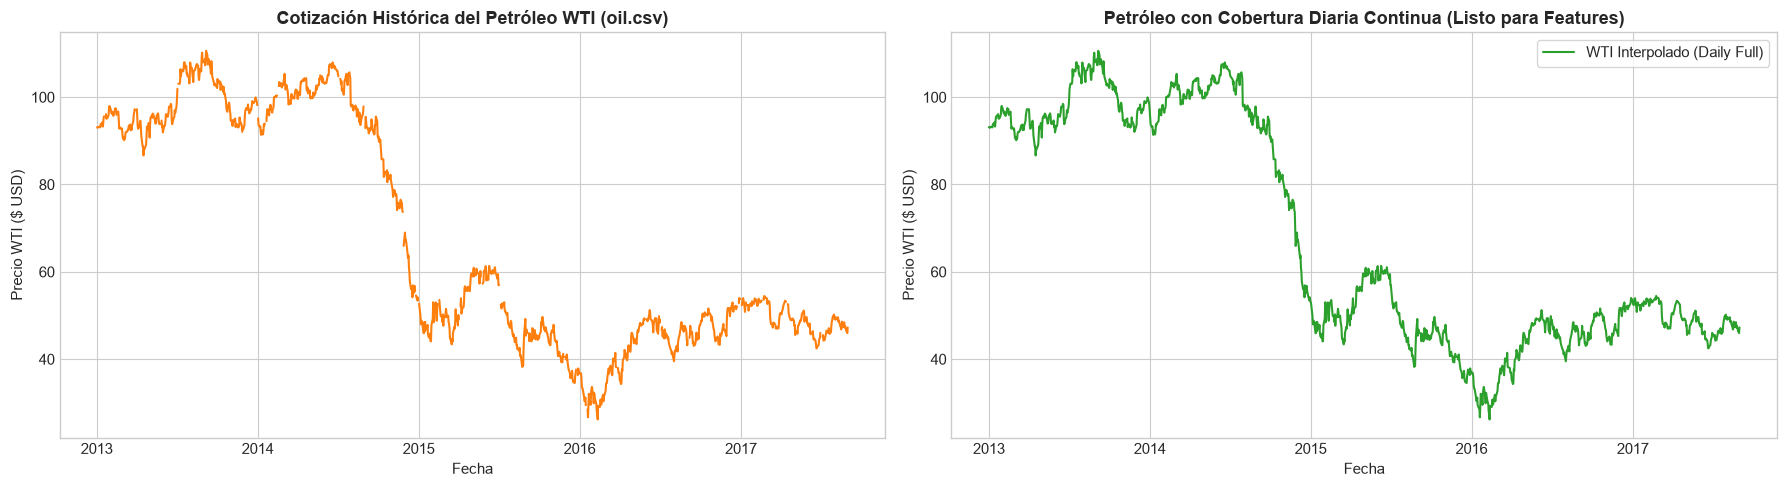

In [11]:
# 1. Petróleo: Análisis de Nulos y Tendencia
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

ax1.plot(oil_df['date'], oil_df['dcoilwtico'], color='#ff7f0e', linewidth=1.5)
ax1.set_title('Cotización Histórica del Petróleo WTI (oil.csv)', fontsize=13)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio WTI ($ USD)')

# Interpolación y completado de fechas para verificar cobertura
oil_full_calendar = pd.date_range(oil_df['date'].min(), oil_df['date'].max(), freq='D')
oil_interpolated = oil_df.set_index('date').reindex(oil_full_calendar).interpolate(method='linear').bfill()

ax2.plot(oil_interpolated.index, oil_interpolated['dcoilwtico'], color='#2ca02c', linewidth=1.5, label='WTI Interpolado (Daily Full)')
ax2.set_title('Petróleo con Cobertura Diaria Continua (Listo para Features)', fontsize=13)
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Precio WTI ($ USD)')
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()

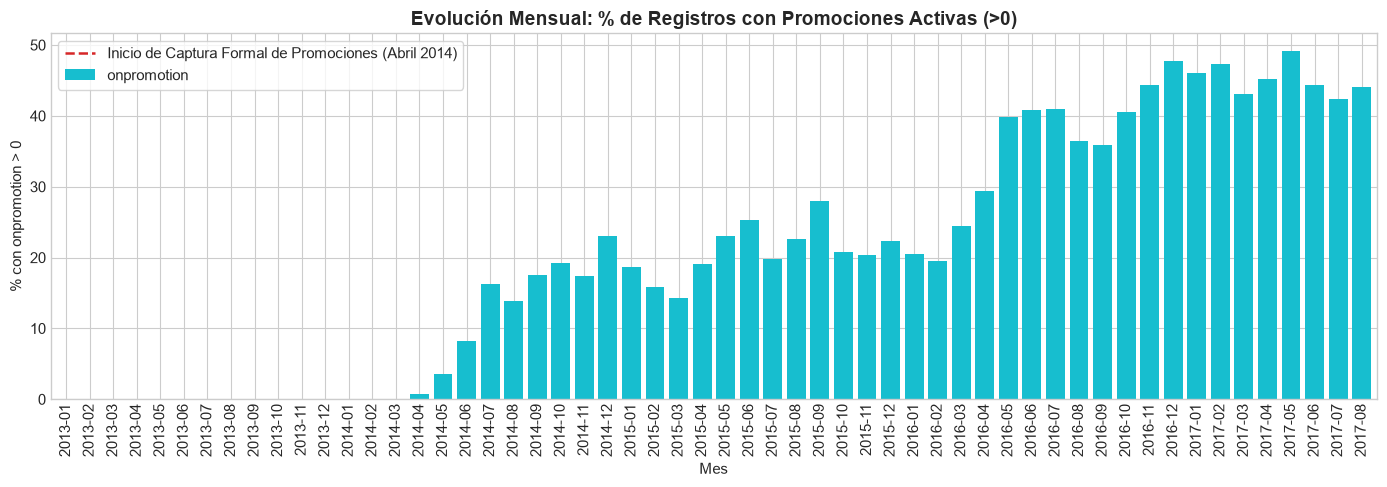

In [12]:
# 2. Promociones: El cambio de captura de datos (2013 vs 2017)
promo_pct_by_date = train_df.groupby(train_df['date'].dt.to_period('M'))['onpromotion'].apply(lambda x: (x > 0).mean() * 100)

fig, ax = plt.subplots(figsize=(14, 5))
promo_pct_by_date.plot(kind='bar', ax=ax, color='#17becf', width=0.8)
ax.set_title('Evolución Mensual: % de Registros con Promociones Activas (>0)', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('% con onpromotion > 0')
ax.axvline(15, color='#d62728', linestyle='--', linewidth=1.8, label='Inicio de Captura Formal de Promociones (Abril 2014)')
ax.legend(frameon=True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 6. Conclusiones Ejecutivas e Implicaciones para el Pipeline

| Factor Descubierto | Causa / Comportamiento | Decisión de Ingeniería / ML |
| :--- | :--- | :--- |
| **Cierre de Navidad** | Tiendas cerradas los 25 de Dic (fechas ausentes en el CSV). | Reindexar serie a calendario completo 365 días imputando $0$ y creando una bandera binaria `is_closed`. |
| **Efecto Quincena** | Picos marcados los días 15, 30 y fin de mes (pago salarial en Ecuador). | Generar variables cíclicas y banderas `is_payday`, `days_to_payday`, `days_since_payday`. |
| **Terremoto 16-Abr-2016** | Spike anómalo temporal en alimentos, agua y productos de limpieza. | Flag de evento atípico `is_earthquake_period` para evitar que el modelo sobreestime la demanda futura regular. |
| **Promociones (2013-2014)** | Cero registro antes de abril de 2014. | Considerar entrenar modelos finales con datos desde **2014-05-01** en adelante para evitar sesgo en el feature `onpromotion`. |
| **Petróleo WTI** | Fines de semana ausentes y 43 nulos. | Pipeline de imputación con Forward-Fill (`ffill`) + lags de 7 y 30 días para capturar shocks macroeconómicos. |
| **Feriados Transferidos** | 12 feriados se trasladaron de día. | Mapear feriados a su fecha efectiva de descanso y filtrar según cobertura (`National`, `Regional` por provincia, `Local` por ciudad). |

---
*Fin del Notebook 01. Siguiente etapa: Implementación de la capa de ingeniería de datos (`src/retail_platform/data_engine/`).*